# Model comparison

This notebook implements the analysis in the study plan. It compares three
methods for estimating the conditional average treatment effect (CATE) across
four scenarios for heterogeneous treatment effects (HTE):

1. No HTE
2. Joint subgroup
3. Published scenario
4. Continuous

The notebook follows the simulation procedure in order:

1. Create one fixed evaluation population.
2. Simulate a randomised trial for each scenario.
3. Fit the classical, Bayesian, and causal forest methods to the same trial.
4. Compare their estimates with the known simulation truth.
5. Repeat the process and summarise CATE RMSE, subgroup difference RMSE,
   and 95% subgroup difference coverage.

The synthetic data generator and scenario definitions are kept in
`config.py`. The separately gated causal forest hyperparameter tuning
experiment below reuses these
functions without changing the main comparison.

In [1]:
from itertools import product
import logging
from time import perf_counter
import warnings

# Hide the missing widget warning from tqdm
warnings.filterwarnings("ignore", message="IProgress not found")

import arviz as az
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.optimize import approx_fprime
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from tqdm.auto import tqdm

import config as cfg

# Hide routine PyMC sampling messages
logging.getLogger("pymc").setLevel(logging.ERROR)

## Analysis settings

All random components derive from `RANDOM_SEED = 42` in `config.py`.
Independent random streams are created for calibration, evaluation, trial
generation, model fitting, BHM prior sensitivity analysis, and causal forest
hyperparameter tuning.

In [2]:
# Create the output folder
OUTPUT_DIRECTORY = cfg.RESULTS_DIRECTORY
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Choose the pilot or final main run
FINAL_RUN = True
RUN_MAIN_ANALYSIS = True
RUN_PRIOR_SENSITIVITY = True
RUN_CAUSAL_FOREST_TUNING = False

if FINAL_RUN:
    N_REPLICATIONS = cfg.MONTE_CARLO_REPLICATIONS
else:
    N_REPLICATIONS = cfg.PILOT_REPLICATIONS

# Set MCMC posterior, warm-up, and chain values
MCMC_DRAWS = 500
MCMC_WARMUP_DRAWS = 500
MCMC_CHAINS = 2
MINIMUM_BULK_ESS = 100

# Set one-at-a-time BHM prior sensitivity specifications
PRIOR_SPECIFICATIONS = (
    {
        "label": "Mean-prior SD 1", "mean_prior_sd": 1.0,
        "heterogeneity_prior_scale": 1.0
    },
    {
        "label": "Primary", "mean_prior_sd": 2.0,
        "heterogeneity_prior_scale": 1.0
    },
    {
        "label": "Mean-prior SD 5", "mean_prior_sd": 5.0,
        "heterogeneity_prior_scale": 1.0
    },
    {
        "label": "Heterogeneity-prior scale 0.5", "mean_prior_sd": 2.0,
        "heterogeneity_prior_scale": 0.5
    },
    {
        "label": "Heterogeneity-prior scale 2", "mean_prior_sd": 2.0,
        "heterogeneity_prior_scale": 2.0
    }
)

## Simulation scenarios

For participant $i$, let $X_i$ denote the vector of baseline covariates and let $Y_i(a)$ denote the potential binary response under treatment arm $a$. Here, $Y_i(a) = 1$ indicates that participant $i$ would achieve at least 5% weight loss under arm $a$, with $a = 0$ for placebo and $a = 1$ for semaglutide. Define

$$
p_{0i} = \Pr(Y_i(0) = 1 \mid X_i)
$$

and

$$
p_{1i} = \Pr(Y_i(1) = 1 \mid X_i)
$$

as the true response probabilities under placebo and semaglutide, respectively. The conditional average treatment effect is

$$
\tau(x) = \mathbb{E}\left[Y(1) - Y(0) \mid X = x\right].
$$

For evaluation participant $i$, define

$$
\tau_i \equiv \tau(X_i) = p_{1i} - p_{0i}.
$$

Thus, $\tau_i$ is the CATE evaluated at participant $i$'s covariates, not an observable individual causal effect. Its estimate is denoted by $\widehat{\tau}_i$.

For subgroups $G_1$ and $G_0$ in the fixed evaluation population, the true and estimated subgroup differences are

$$
D
=
\frac{1}{|G_1|} \sum_{i \in G_1} \tau_i
-
\frac{1}{|G_0|} \sum_{i \in G_0} \tau_i
$$

and

$$
\widehat{D}
=
\frac{1}{|G_1|} \sum_{i \in G_1} \widehat{\tau}_i
-
\frac{1}{|G_0|} \sum_{i \in G_0} \widehat{\tau}_i.
$$

For No HTE and Published scenario, $G_1$ is age $\geq 65$ and $G_0$ is age $< 65$. For Joint subgroup, $G_1$ is BMI $\geq 40$ with prediabetes and $G_0$ is all others. For Continuous, $G_1$ and $G_0$ are the upper and lower age quartiles in the fixed evaluation population, with the middle 50% excluded from the subgroup-difference calculation.

### Common placebo model

Define

$$
\begin{aligned}
F_i &= \mathbb{I}(\mathrm{Female}_i = 1),\\
A_i &= \mathbb{I}(\mathrm{Age}_i \geq 65),\\
B_{35,i} &= \mathbb{I}(35 \leq \mathrm{BMI}_i < 40),\\
B_{40,i} &= \mathbb{I}(\mathrm{BMI}_i \geq 40),\\
P_i &= \mathbb{I}(\mathrm{Prediabetes}_i = 1).
\end{aligned}
$$

The reference categories are male, age below 65 years, BMI 30 to below 35, and normoglycaemia.

Define the fixed baseline-risk score determined by the prespecified subgroup characteristics as

$$
m(X_i)
=
\lambda_F F_i
+
\lambda_A A_i
+
\lambda_{35} B_{35,i}
+
\lambda_{40} B_{40,i}
+
\lambda_P P_i,
$$

where, for $j \in \{F,A,35,40,P\}$,

$$
\lambda_j
=
0.6
\log
\left(
\frac{\text{placebo odds in subgroup }j}
{\text{placebo odds in the corresponding reference subgroup}}
\right).
$$

The placebo response model is

$$
\operatorname{logit}(p_{0i})
=
\alpha_0 + m(X_i).
$$

Let $N_{\mathrm{cal}}$ denote the size of the fixed calibration population. The intercept $\alpha_0$ is calibrated so that

$$
\frac{1}{N_{\mathrm{cal}}} \sum_{i=1}^{N_{\mathrm{cal}}} p_{0i} = \frac{63}{201}.
$$

This placebo model is common to all four scenarios.

### 1. No HTE

Define

$$
\Delta
=
\frac{862}{1005}
-
\frac{63}{201}.
$$

The semaglutide response probability is

$$
p_{1i} = p_{0i} + \Delta.
$$

Therefore,

$$
\tau_i
=
p_{1i} - p_{0i}
=
\Delta
$$

for every participant.

Thus, the true treatment effect is constant on the risk-difference scale.

### 2. Joint subgroup

Define

$$
J_i
=
\mathbb{I}\left(\mathrm{BMI}_i \geq 40\ \text{ and }\ P_i = 1\right).
$$

The semaglutide log-odds are

$$
\operatorname{logit}(p_{1i})
=
\operatorname{logit}(p_{0i})
+
\alpha_J
+
2 J_i.
$$

Equivalently,

$$
p_{1i}
=
\frac{1}
{1 + \exp\left[-\left\{
\operatorname{logit}(p_{0i})
+ \alpha_J
+ 2 J_i
\right\}\right]}.
$$

The coefficient $2$ is a prespecified strong synthetic treatment-effect modifier for participants with both BMI $\geq 40$ and prediabetes.

The intercept $\alpha_J$ is calibrated so that

$$
\frac{1}{N_{\mathrm{cal}}} \sum_{i=1}^{N_{\mathrm{cal}}} p_{1i} = \frac{862}{1005}.
$$

The true CATE is

$$
\tau_i
=
p_{1i} - p_{0i}.
$$

### 3. Published scenario

Define the treatment-effect modifier

$$
h(X_i)
=
\delta_F F_i
+
\delta_A A_i
+
\delta_{35} B_{35,i}
+
\delta_{40} B_{40,i}
+
\delta_P P_i,
$$

where, for $j \in \{F,A,35,40,P\}$,

$$
\delta_j = \log\left(\frac{\mathrm{OR}_j}{\mathrm{OR}_{\mathrm{ref},j}}\right).
$$

$\mathrm{OR}_j$ is the published odds ratio for subgroup $j$, and $\mathrm{OR}_{\mathrm{ref},j}$ is the published odds ratio for the corresponding reference subgroup.

Specifically,

$$
\delta_F
=
\log\left(\frac{11.4}{14.4}\right),
$$

$$
\delta_A
=
\log\left(\frac{4.6}{12.9}\right),
$$

$$
\delta_{35}
=
\log\left(\frac{15.7}{11.4}\right),
$$

$$
\delta_{40}
=
\log\left(\frac{10.7}{11.4}\right),
$$

and

$$
\delta_P
=
\log\left(\frac{9.1}{14.7}\right).
$$

The published subgroup odds ratios define the synthetic treatment-effect pattern in the data-generating process, and their differences are not interpreted as evidence of statistically significant treatment-effect modification.

The semaglutide log-odds are

$$
\operatorname{logit}(p_{1i})
=
\operatorname{logit}(p_{0i})
+
\alpha_{\mathrm{Pub}}
+
h(X_i).
$$

Equivalently,

$$
p_{1i}
=
\frac{1}
{1 + \exp\left[-\left\{
\operatorname{logit}(p_{0i})
+ \alpha_{\mathrm{Pub}}
+ h(X_i)
\right\}\right]}.
$$

The intercept $\alpha_{\mathrm{Pub}}$ is calibrated so that

$$
\frac{1}{N_{\mathrm{cal}}} \sum_{i=1}^{N_{\mathrm{cal}}} p_{1i} = \frac{862}{1005}.
$$

The true CATE is

$$
\tau_i
=
p_{1i} - p_{0i}.
$$

### 4. Continuous

Define standardised age as

$$
Z_{\mathrm{age},i}
=
\frac{\mathrm{Age}_i - \mu_{\mathrm{age}}}{\sigma_{\mathrm{age}}},
$$

where $\mu_{\mathrm{age}}$ and $\sigma_{\mathrm{age}}$ are the mean and standard deviation of age in the fixed calibration population.

The semaglutide log-odds are

$$
\operatorname{logit}(p_{1i})
=
\operatorname{logit}(p_{0i})
+
\alpha_C
-
0.5 Z_{\mathrm{age},i}.
$$

Equivalently,

$$
p_{1i}
=
\frac{1}
{1 + \exp\left[-\left\{
\operatorname{logit}(p_{0i})
+ \alpha_C
- 0.5 Z_{\mathrm{age},i}
\right\}\right]}.
$$

The coefficient $-0.5$ is a prespecified synthetic treatment-effect modifier, so the treatment log-odds effect decreases linearly with standardised age.

The intercept $\alpha_C$ is calibrated so that

$$
\frac{1}{N_{\mathrm{cal}}} \sum_{i=1}^{N_{\mathrm{cal}}} p_{1i} = \frac{862}{1005}.
$$

The true CATE is

$$
\tau_i
=
p_{1i} - p_{0i}.
$$

In [3]:
def normal_interval(estimate, standard_error):
    """Return a normal 95% interval in a small dictionary"""
    estimate = float(estimate)
    standard_error = float(standard_error)

    # Use a normal approximation
    return {
        "estimate": estimate,
        "standard_error": standard_error,
        "lower": estimate - 1.96 * standard_error,
        "upper": estimate + 1.96 * standard_error
    }

def posterior_interval(draws):
    """Summarise draws by posterior mean, SD, and 95% quantile interval"""
    draws = np.asarray(draws, dtype=float).reshape(-1)
    # Calculate the 2.5% and 97.5% quantiles
    lower, upper = np.quantile(draws, [0.025, 0.975])

    return {
        # Use the posterior mean as the point estimate
        "estimate": float(draws.mean()),
        # Store posterior SD under the shared standard_error key for compatibility
        "standard_error": float(draws.std(ddof=1)),
        "lower": float(lower),
        "upper": float(upper)
    }

def subgroup_difference(cate, groups):
    """Compare the mean CATE in group one with the mean in group zero"""
    # Compare the two group averages
    group_one_effect = cate[groups["group_one"]].mean()
    group_zero_effect = cate[groups["group_zero"]].mean()
    return float(group_one_effect - group_zero_effect)

def define_evaluation_subgroups(data, scenario):
    """Define subgroups using the fixed evaluation population"""
    if scenario != "continuous":
        return cfg.define_subgroups(data, scenario)
    lower, upper = CONTINUOUS_AGE_QUARTILES
    age = data["age_years"].to_numpy()
    return {
        "label": "upper minus lower age quartile",
        "group_one": age >= upper,
        "group_zero": age <= lower
    }

def validate_saved_results(data, required_columns, analysis_name):
    """Check that saved results match the current simulation design"""
    missing_columns = sorted(set(required_columns) - set(data.columns))
    if missing_columns:
        raise ValueError(
            f"Saved results for {analysis_name} are missing required columns "
            f"{missing_columns}. Rerun {analysis_name}."
        )
    saved_scenarios = set(data["scenario"].dropna())
    current_scenarios = set(cfg.PRIMARY_ANALYSIS_SCENARIOS)
    if saved_scenarios != current_scenarios:
        raise ValueError(
            f"Saved results for {analysis_name} use scenarios "
            f"{sorted(saved_scenarios)}, "
            f"not the current scenarios {sorted(current_scenarios)}. "
            f"Rerun {analysis_name}."
        )

MODEL_FACTOR_COLUMNS = ["female", "age_65", "bmi_35_to_40", "bmi_40", "prediabetes"]

def prepare_analysis_data(data):
    """Add model factors from the subgroup labels created in config.py"""
    prepared = data.copy()
    prepared["age_65"] = prepared["age_group"].eq("65 or older").astype(int)
    prepared["bmi_35_to_40"] = prepared["bmi_group"].eq("35 to under 40").astype(int)
    prepared["bmi_40"] = prepared["bmi_group"].eq("40 or higher").astype(int)
    return prepared

def calculate_truth(evaluation_data, scenario):
    """Calculate the known truth for one scenario"""
    # Use hidden probabilities only for evaluation
    placebo_probability, treated_probability = cfg.calculate_outcome_probabilities(
        evaluation_data, scenario
    )
    true_cate = treated_probability - placebo_probability
    groups = define_evaluation_subgroups(evaluation_data, scenario)

    return {
        "cate": true_cate,
        "subgroup_difference": subgroup_difference(true_cate, groups)
    }

## Method 1. Classical interaction model

The classical method uses logistic regression with treatment, five prespecified subgroup indicators, and their treatment-by-subgroup interactions. Here, $T_i = 1$ denotes semaglutide and $T_i = 0$ denotes placebo, while $Y_i = Y_i(T_i)$ is the observed binary response:

$$
\operatorname{logit}\left\{\Pr(Y_i = 1 \mid T_i, X_i)\right\}
=
\beta_0
+ \beta_T T_i
+ \beta_F F_i
+ \beta_A A_i
+ \beta_{35} B_{35,i}
+ \beta_{40} B_{40,i}
+ \beta_P P_i
+ \gamma_F T_i F_i
+ \gamma_A T_i A_i
+ \gamma_{35} T_i B_{35,i}
+ \gamma_{40} T_i B_{40,i}
+ \gamma_P T_i P_i,
$$

where

$$
\begin{aligned}
F_i &= \mathbb{I}(\mathrm{Female}_i = 1),\\
A_i &= \mathbb{I}(\mathrm{Age}_i \geq 65),\\
B_{35,i} &= \mathbb{I}(35 \leq \mathrm{BMI}_i < 40),\\
B_{40,i} &= \mathbb{I}(\mathrm{BMI}_i \geq 40),\\
P_i &= \mathbb{I}(\mathrm{Prediabetes}_i = 1).
\end{aligned}
$$

$\beta_0$ is the fitted intercept and $\beta_T$ is the fitted treatment main-effect coefficient. The coefficients $\beta_F$, $\beta_A$, $\beta_{35}$, $\beta_{40}$ and $\beta_P$ are the main-effect coefficients for the subgroup indicators, while $\gamma_F$, $\gamma_A$, $\gamma_{35}$, $\gamma_{40}$ and $\gamma_P$ are the treatment-by-subgroup interaction coefficients.

In [4]:
def make_classical_design(data, treatment):
    """Create the columns used in the classical logistic regression"""
    # Use one treatment value for every row when needed
    if np.isscalar(treatment):
        treated = np.repeat(treatment, len(data))
    else:
        treated = np.asarray(treatment)

    # Reuse the subgroup indicators above
    subgroup_design = data[MODEL_FACTOR_COLUMNS]
    main_design = pd.DataFrame({"intercept": 1.0, "treated": treated}, index=data.index)
    interactions = subgroup_design.mul(treated, axis=0).add_prefix("treated_x_")
    return pd.concat([main_design, subgroup_design, interactions], axis=1)

def predict_classical_cate(coefficients, evaluation_data):
    """Predict each person's risk under treatment and placebo"""
    # Predict the same people under both arms
    treated_design = make_classical_design(evaluation_data, treatment=1)
    placebo_design = make_classical_design(evaluation_data, treatment=0)

    treated_risk = cfg.inverse_logit(treated_design @ coefficients)
    placebo_risk = cfg.inverse_logit(placebo_design @ coefficients)

    return treated_risk - placebo_risk

The delta method needs the slope of the subgroup difference with respect to
every regression coefficient. `approx_fprime` calculates these slopes by
making a very small change to each coefficient. This avoids writing the
matrix derivative by hand while keeping the same delta-method analysis.

In [5]:
def fit_classical_model(data, evaluation_data, scenario):
    """Fit the classical model and return the results"""
    # Create the design matrix for the classical logistic regression
    observed_design = make_classical_design(data, treatment=data["treated"].to_numpy())

    # Fit logistic regression with heteroskedasticity-robust standard errors
    fitted_model = sm.GLM(
        data["weight_loss_5pct"], observed_design, family=sm.families.Binomial()
    ).fit(cov_type="HC0", maxiter=100)

    # Extract coefficients and covariance matrix
    coefficients = fitted_model.params.to_numpy()
    covariance = fitted_model.cov_params().to_numpy()
    groups = define_evaluation_subgroups(evaluation_data, scenario)

    # Estimate individual and subgroup effects
    cate = predict_classical_cate(coefficients, evaluation_data)
    point_estimate = subgroup_difference(cate, groups)

    # Recalculate the subgroup difference after small coefficient changes
    def recalculate_difference(changed_coefficients):
        changed_cate = predict_classical_cate(changed_coefficients, evaluation_data)
        return subgroup_difference(changed_cate, groups)

    # Approximate the delta method gradient
    gradient = approx_fprime(coefficients, recalculate_difference, epsilon=1e-6)
    variance = gradient @ covariance @ gradient
    standard_error = np.sqrt(max(float(variance), 0))

    return {
        "method": "classical_interaction",
        "subgroup_difference_result": normal_interval(point_estimate, standard_error),
        "cate": cate,
        "converged": bool(fitted_model.converged),
        "diagnostic": ""
    }

## Method 2. Bayesian hierarchical model

The Bayesian hierarchical model uses 24 mutually exclusive strata formed from

$$
2\text{ sex groups}
\times
2\text{ age groups}
\times
3\text{ BMI groups}
\times
2\text{ glycaemic-status groups}
=
24.
$$

Let $a \in \{0,1\}$ denote treatment arm, where $a = 0$ is placebo and $a = 1$ is semaglutide, and let $k = 1,\ldots,24$ denote stratum. The Python implementation uses zero-based array indices internally.

For each arm and stratum,

$$
R_{a,k}
\sim
\operatorname{Binomial}(n_{a,k}, p_{a,k}),
$$

where $R_{a,k}$ is the number of responders among $n_{a,k}$ participants in treatment arm $a$ and stratum $k$.

The stratum-specific log-odds, or linear predictors, are

$$
\eta_{a,k}
=
\mu_a + \sigma_a z_{a,k},
$$

where

$$
z_{a,k} \sim N(0,1).
$$

The primary priors are

$$
\mu_a \sim N(0,2^2)
$$

and

$$
\sigma_a \sim \operatorname{HalfNormal}(1).
$$

The corresponding response probability is

$$
p_{a,k}
=
\frac{1}
{1 + \exp(-\eta_{a,k})}.
$$

The stratum-specific CATE is therefore

$$
\tau_k
=
p_{1,k} - p_{0,k}.
$$

Here, $\mu_a$ is the arm-specific mean log-odds, $\sigma_a$ is the between-stratum standard deviation, and $z_{a,k}$ is the standardised stratum-specific deviation. Thus, $\sigma_a z_{a,k}$ is the corresponding deviation in log-odds from the arm-specific mean.

In [6]:
N_STRATA = 24

def find_stratum(data):
    """Assign every participant to one of the 24 strata"""
    indicators = data[MODEL_FACTOR_COLUMNS]
    bmi_group = indicators["bmi_35_to_40"] + 2 * indicators["bmi_40"]

    # Give each factor combination one index
    stratum = (
        indicators["female"] * 12
        + indicators["age_65"] * 6
        + bmi_group * 2
        + indicators["prediabetes"]
    )
    return stratum.to_numpy(dtype=int)

def count_stratum_outcomes(data):
    """Count participants and responses by arm and stratum"""
    stratum = find_stratum(data)
    treated = data["treated"].to_numpy(dtype=int)
    outcome = data["weight_loss_5pct"].to_numpy(dtype=int)

    # Store placebo in row 0 and treatment in row 1
    totals = np.zeros((2, N_STRATA), dtype=int)
    responses = np.zeros((2, N_STRATA), dtype=int)

    # Count participants and responses
    for arm in [0, 1]:
        in_arm = treated == arm
        totals[arm] = np.bincount(stratum[in_arm], minlength=N_STRATA)
        responses[arm] = np.bincount(
            stratum[in_arm], weights=outcome[in_arm], minlength=N_STRATA
        ).astype(int)

    return totals, responses

In [7]:
def fit_bayesian_model(
    data, evaluation_data, scenario, fit_seed, mean_prior_sd=2.0,
    heterogeneity_prior_scale=1.0
):
    """Fit the Bayesian hierarchical model"""
    totals, responses = count_stratum_outcomes(data)

    with pm.Model() as model:
        # Set arm-level priors
        global_log_odds = pm.Normal(
            "global_log_odds", mu=0, sigma=mean_prior_sd, shape=2
        )
        heterogeneity = pm.HalfNormal(
            "heterogeneity", sigma=heterogeneity_prior_scale, shape=2
        )
        # Set partially pooled stratum effects
        stratum_z = pm.Normal("stratum_z", mu=0, sigma=1, shape=(2, N_STRATA))
        # Calculate stratum-specific log-odds
        log_odds = global_log_odds[:, None] + heterogeneity[:, None] * stratum_z
        # Convert log-odds to probabilities
        probability = pm.Deterministic("probability", pm.math.sigmoid(log_odds))

        # Use aggregated binomial observations
        pm.Binomial("responses", n=totals, p=probability, observed=responses)

        # Draw from the posterior
        posterior = pm.sample(
            draws=MCMC_DRAWS,
            tune=MCMC_WARMUP_DRAWS,
            chains=MCMC_CHAINS,
            cores=1,
            target_accept=0.95,
            random_seed=fit_seed,
            progressbar=False,
            compute_convergence_checks=False
        )

    # Extract the probability draws
    probability_draws = np.asarray(posterior.posterior["probability"], dtype=float)
    # Assign evaluation participants to strata
    evaluation_stratum = find_stratum(evaluation_data)

    # Convert arm probabilities into CATE draws
    cate_draws = (
        probability_draws[:, :, 1, evaluation_stratum]
        - probability_draws[:, :, 0, evaluation_stratum]
    )

    # Calculate the subgroup difference for every draw
    groups = define_evaluation_subgroups(evaluation_data, scenario)
    subgroup_difference_draws = cate_draws[:, :, groups["group_one"]].mean(
        axis=2
    ) - cate_draws[:, :, groups["group_zero"]].mean(axis=2)

    # Calculate diagnostics for model parameters
    model_diagnostics = az.summary(
        posterior, var_names=["global_log_odds", "heterogeneity", "probability"]
    )
    # Check the maximum R-hat, which should be close to one
    max_rhat = float(model_diagnostics["r_hat"].max())
    # Check minimum bulk effective sample size (the larger the better)
    minimum_bulk_ess = float(model_diagnostics["ess_bulk"].min())

    # Check the primary subgroup estimate
    subgroup_rhat = float(np.asarray(az.rhat(subgroup_difference_draws)))
    subgroup_ess = float(
        np.asarray(az.ess(subgroup_difference_draws, method="bulk"))
    )
    # Combine the diagnostics results
    max_rhat = max(max_rhat, subgroup_rhat)
    minimum_bulk_ess = min(minimum_bulk_ess, subgroup_ess)

    # Check for divergences (ideally zero)
    divergences = int(posterior.sample_stats["diverging"].sum())

    # Mark the model as converged only when every diagnostic passes
    converged = (
        max_rhat < 1.05 and minimum_bulk_ess >= MINIMUM_BULK_ESS and divergences == 0
    )

    # Calculate the posterior mean CATE
    cate = cate_draws.mean(axis=(0, 1))

    return {
        "method": "bayesian_hierarchical",
        "subgroup_difference_result": posterior_interval(
            subgroup_difference_draws
        ),
        "cate": cate,
        "converged": converged,
        "diagnostic": (
            f"mean prior SD={mean_prior_sd:g}, "
            f"heterogeneity prior scale={heterogeneity_prior_scale:g}, "
            f"max R-hat={max_rhat:.3f}, "
            f"minimum bulk ESS={minimum_bulk_ess:.0f}, "
            f"divergences={divergences}"
        )
    }

## Method 3. Causal forest

The causal forest is fitted using EconML with continuous age, sex, continuous BMI and prediabetes as baseline covariates.

For a participant with covariates $X = x$, the target is the conditional average treatment effect

$$
\tau(x)
=
\mathbb{E}\left[Y(1) - Y(0) \mid X = x\right].
$$

The causal forest estimates this function flexibly using an ensemble of honest causal trees, without imposing a prespecified parametric form for the treatment-by-covariate relationships.

The fitted forest is then used to predict $\widehat{\tau}_i$ for each participant in the fixed evaluation population.

For the prespecified subgroup comparison, the subgroup difference is the mean estimated CATE in group one minus the mean estimated CATE in group zero.

For $g \in \{0,1\}$, the mean estimated CATE in subgroup $G_g$ is

$$
\widehat{\tau}_{G_g}
=
\frac{1}{|G_g|} \sum_{i \in G_g} \widehat{\tau}_i.
$$

The 95% subgroup-difference interval uses

$$
\operatorname{SE}(\widehat{D})
\approx
\sqrt{
\operatorname{SE}(\widehat{\tau}_{G_1})^2
+
\operatorname{SE}(\widehat{\tau}_{G_0})^2
}.
$$

The covariance between the two subgroup estimates is not available from the EconML interface used here, so the resulting interval and coverage are approximate.

In [8]:
def get_baseline_features(data):
    """Return the baseline variables used by the causal forest"""
    return data[cfg.BASELINE_COLUMNS].to_numpy(dtype=float)

def population_standard_error(effect_inference):
    """Get the standard error of a population mean effect"""
    summary = effect_inference.population_summary(alpha=0.05)
    return float(np.asarray(summary.stderr_mean).squeeze())

# Final settings selected by causal forest hyperparameter tuning
CAUSAL_FOREST_SETTINGS = {
    "min_samples_leaf": 20,
    "max_samples": 0.45,
    "max_depth": 5
}

CAUSAL_FOREST_TUNING_REPLICATIONS = 30

# Candidate settings used for causal forest hyperparameter tuning
CAUSAL_FOREST_TUNING_GRID = {
    "min_samples_leaf": (5, 10, 20),
    "max_samples": (0.45, 0.50),
    "max_depth": (None, 5)
}

def fit_causal_forest(
    data, evaluation_data, scenario, fit_seed, forest_settings=None
):
    """Fit the causal forest and return the required results"""
    settings = CAUSAL_FOREST_SETTINGS if forest_settings is None else forest_settings

    # Define the nuisance and forest models
    forest = CausalForestDML(
        model_y=RandomForestClassifier(
            n_estimators=100,
            min_samples_leaf=10,
            max_features="sqrt",
            random_state=fit_seed,
            n_jobs=1
        ),
        model_t=DummyClassifier(strategy="prior"),
        discrete_outcome=True,
        discrete_treatment=True,
        cv=3,
        n_estimators=400,
        min_samples_leaf=settings["min_samples_leaf"],
        max_samples=settings["max_samples"],
        criterion="mse",
        max_depth=settings["max_depth"],
        honest=True,
        inference=True,
        random_state=fit_seed,
        n_jobs=1
    )

    # Fit the simulated trial
    forest.fit(
        data["weight_loss_5pct"].to_numpy(dtype=int),
        data["treated"].to_numpy(dtype=int),
        X=get_baseline_features(data),
        inference="auto"
    )

    # Predict CATEs in the evaluation population
    evaluation_features = get_baseline_features(evaluation_data)
    cate = np.asarray(forest.effect(evaluation_features), dtype=float).reshape(-1)

    # Estimate the prespecified subgroup difference
    groups = define_evaluation_subgroups(evaluation_data, scenario)
    point_estimate = subgroup_difference(cate, groups)

    group_one_inference = forest.effect_inference(
        evaluation_features[groups["group_one"]]
    )
    group_zero_inference = forest.effect_inference(
        evaluation_features[groups["group_zero"]]
    )

    # Combine the two subgroup standard errors
    standard_error = np.sqrt(
        population_standard_error(group_one_inference) ** 2
        + population_standard_error(group_zero_inference) ** 2
    )

    return {
        "method": "causal_forest",
        "subgroup_difference_result": normal_interval(
            point_estimate, standard_error
        ),
        "cate": cate,
        "converged": True,
        "diagnostic": "Approximate interval with subgroup covariance omitted"
    }

## Fixed evaluation population

Each fitted method predicts CATEs for the same independently generated
population of 1,000 people. This population is held fixed across simulation
replications and is used only to evaluate model performance. Models are fitted
using separate simulated trial data. The Continuous scenario uses age quartiles
calculated once in this population. Its middle 50% remains in CATE RMSE but is
excluded from the subgroup difference.

In [9]:
# Link method names to fitting functions
METHODS = {
    "classical_interaction": fit_classical_model,
    "bayesian_hierarchical": fit_bayesian_model,
    "causal_forest": fit_causal_forest
}

# Create one fixed evaluation population
evaluation_random_generator = cfg.create_random_generators()["evaluation"]
evaluation_population = prepare_analysis_data(
    cfg.simulate_baseline(cfg.EVALUATION_N, evaluation_random_generator)
)
CONTINUOUS_AGE_QUARTILES = tuple(
    np.quantile(evaluation_population["age_years"], [0.25, 0.75])
)

# Save the true values for each scenario
scenario_truth = {}
for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
    scenario_truth[scenario] = calculate_truth(evaluation_population, scenario)

## True treatment-effect scenarios

The figure shows the true arm risks and CATE distributions in the fixed
evaluation population before any Monte Carlo model fitting.

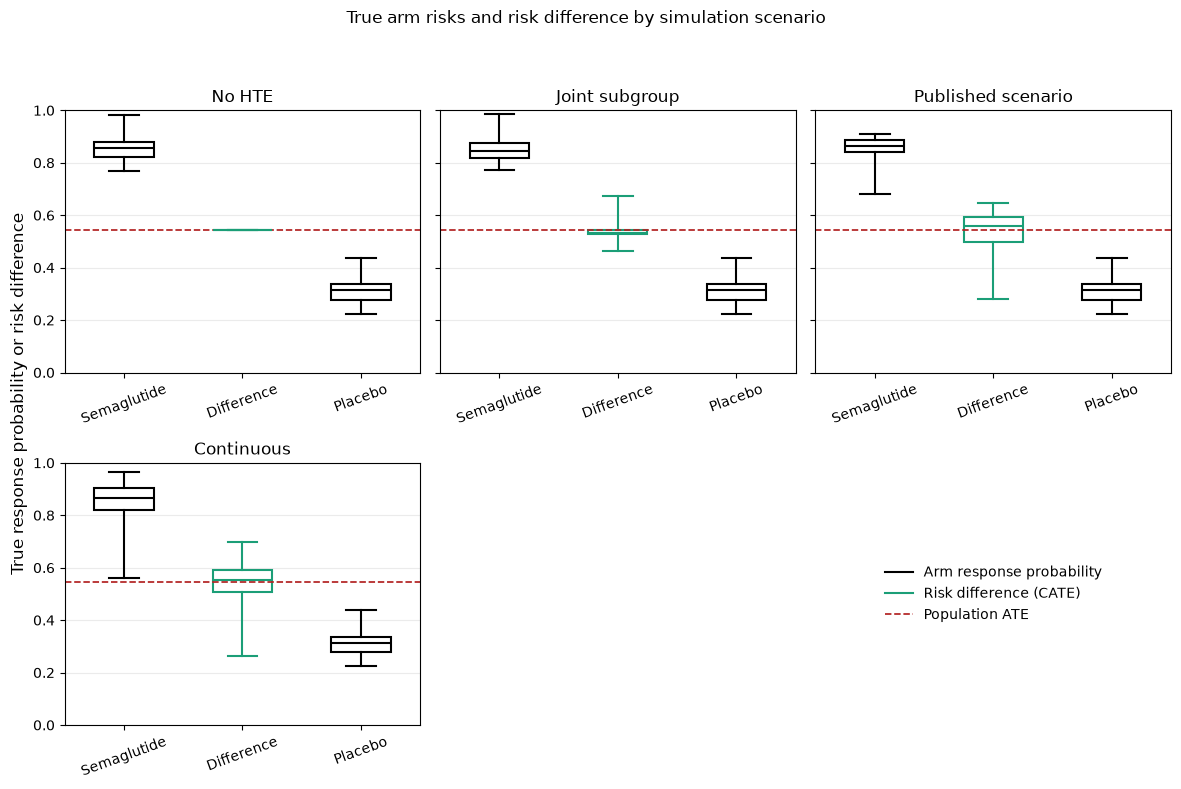

In [10]:
def plot_true_arm_and_difference_boxplots(evaluation_data, path, title=None):
    """Plot both true arm risks and their difference for every scenario"""
    figure, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
    difference_color = "#1B9E77"

    for axis, scenario in zip(axes.flat, cfg.PRIMARY_ANALYSIS_SCENARIOS):
        placebo_risk, semaglutide_risk = cfg.calculate_outcome_probabilities(
            evaluation_data, scenario
        )
        risk_difference = semaglutide_risk - placebo_risk
        boxplot = axis.boxplot(
            [semaglutide_risk, risk_difference, placebo_risk],
            positions=[1, 2, 3],
            widths=0.5,
            whis=(0, 100),
            showfliers=False,
            patch_artist=True,
            medianprops={"color": "black", "linewidth": 1.5},
            boxprops={"edgecolor": "black", "linewidth": 1.5},
            whiskerprops={"color": "black", "linewidth": 1.5},
            capprops={"color": "black", "linewidth": 1.5}
        )

        for box in boxplot["boxes"]:
            box.set_facecolor("white")

        # Highlight the risk-difference distribution
        boxplot["boxes"][1].set_edgecolor(difference_color)
        boxplot["medians"][1].set_color(difference_color)
        for line in boxplot["whiskers"][2:4] + boxplot["caps"][2:4]:
            line.set_color(difference_color)

        axis.axhline(
            cfg.ATE_TARGET, color="#B22222", linestyle="--", linewidth=1.25
        )
        axis.set_title(cfg.SCENARIO_LABELS[scenario])
        axis.set_xticks(
            [1, 2, 3], ["Semaglutide", "Difference", "Placebo"], rotation=20
        )
        axis.set_ylim(0, 1)
        axis.grid(axis="y", alpha=0.25)

    axes.flat[-2].axis("off")
    legend_axis = axes.flat[-1]
    legend_axis.axis("off")
    legend_axis.plot(
        [], [], color="black", linewidth=1.5, label="Arm response probability"
    )
    legend_axis.plot(
        [], [], color=difference_color, linewidth=1.5, label="Risk difference (CATE)"
    )
    legend_axis.plot(
        [], [], color="#B22222", linestyle="--", linewidth=1.25,
        label="Population ATE"
    )
    legend_axis.legend(loc="center", frameon=False)
    figure.supylabel("True response probability or risk difference")
    if title is not None:
        figure.suptitle(title)
    top = 0.94 if title is not None else 1
    figure.tight_layout(rect=(0, 0, 1, top))
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return figure

true_cate_figure = plot_true_arm_and_difference_boxplots(
    evaluation_population,
    OUTPUT_DIRECTORY / "true_cate_scenarios.png",
    title="True arm risks and risk difference by simulation scenario"
)
truth_no_title_path = OUTPUT_DIRECTORY / "true_cate_scenarios_no_title.png"
truth_figure_no_title = plot_true_arm_and_difference_boxplots(
    evaluation_population, truth_no_title_path
)
plt.close(truth_figure_no_title)

## Prepare and store simulation results

The simulation saves one row for every scenario, replication, and method.
Failed fits are kept in the results rather than silently removed.

In [11]:
def make_successful_row(fitted, truth, scenario, replication):
    """Convert a successful model fit into one table row"""
    # Calculate errors against the known truth
    subgroup_difference_result = fitted["subgroup_difference_result"]
    estimation_error = (
        subgroup_difference_result["estimate"] - truth["subgroup_difference"]
    )
    cate_mse = np.mean((fitted["cate"] - truth["cate"]) ** 2)

    return {
        "scenario": scenario,
        "replication": replication,
        "method": fitted["method"],
        "success": True,
        "converged": fitted["converged"],
        "diagnostic": fitted["diagnostic"],
        "error": "",
        "subgroup_difference_truth": truth["subgroup_difference"],
        "subgroup_difference_estimate": subgroup_difference_result["estimate"],
        "subgroup_difference_standard_error": subgroup_difference_result[
            "standard_error"
        ],
        "subgroup_difference_lower": subgroup_difference_result["lower"],
        "subgroup_difference_upper": subgroup_difference_result["upper"],
        "subgroup_difference_error": estimation_error,
        "subgroup_difference_covered": (
            subgroup_difference_result["lower"]
            <= truth["subgroup_difference"]
            <= subgroup_difference_result["upper"]
        ),
        "cate_mse": cate_mse
    }

def make_failed_row(method, scenario, replication, exception):
    """Store a failed fit using the same identifying columns"""
    return {
        "scenario": scenario,
        "replication": replication,
        "method": method,
        "success": False,
        "converged": False,
        "diagnostic": "",
        "error": f"{type(exception).__name__}: {exception}"
    }

def simulate_one_trial(random_generator, scenario):
    """Generate one trial and return the columns available to an analyst"""
    baseline = cfg.simulate_baseline(cfg.TOTAL_N, random_generator)
    trial, _ = cfg.simulate_trial(baseline, random_generator, scenario=scenario)
    # Prepare the shared subgroup factors for the classical and Bayesian methods
    factor_labels = ["age_group", "bmi_group"]
    return prepare_analysis_data(trial[[*cfg.ANALYSIS_COLUMNS, *factor_labels]])

## Run the main simulation

Within each replication, all three methods are fitted to the same simulated trial.
This creates a paired comparison at the trial level. The live progress bar updates after
every model fit and reports elapsed time and estimated time remaining. The
final analysis contains 6,000 model fits across 500 replications per scenario.
A pilot with 10 replications per scenario contains 120 model fits.

In [12]:
def run_main_simulation(replications):
    """Run every method for every scenario and replication"""
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["main_trials"]
    model_random_generator = random_generators["main_models"]
    rows = []
    total_fits = len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(METHODS)
    progress = tqdm(
        total=total_fits, desc="Main simulation", unit="fit", dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # Generate one trial shared by all methods
            analysis_data = simulate_one_trial(trial_random_generator, scenario)

            for method_name, fit_method in METHODS.items():
                progress.set_postfix_str(
                    f"{cfg.SCENARIO_LABELS[scenario]} | "
                    f"replication {replication}/{replications} | "
                    f"{cfg.METHOD_LABELS[method_name]}"
                )
                try:
                    if method_name == "classical_interaction":
                        fitted = fit_method(
                            analysis_data, evaluation_population, scenario
                        )
                    else:
                        # Give each stochastic fit its own reproducible seed
                        fit_seed = int(model_random_generator.integers(0, 2**32))
                        fitted = fit_method(
                            analysis_data, evaluation_population, scenario, fit_seed
                        )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    # Keep failed fits in the output
                    row = make_failed_row(method_name, scenario, replication, exception)

                rows.append(row)
                progress.update(1)

        progress.write(
            f"Completed {cfg.SCENARIO_LABELS[scenario]} "
            f"({replications} replications)"
        )

    progress.close()

    # Save replication level results
    results = pd.DataFrame(rows)
    results.to_csv(OUTPUT_DIRECTORY / "replication_results.csv", index=False)
    return results

## Summarise the simulation

Accuracy measures use only successful fits that passed the convergence
checks. Failure and non-convergence rates use all attempted fits.

In [13]:
def root_mean_square(values):
    """Calculate the root mean square of a set of values"""
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan
    return np.sqrt(np.mean(values**2))

def binomial_mcse(rate, number_of_replications):
    """Calculate Monte Carlo standard error for a proportion"""
    if number_of_replications == 0:
        return np.nan
    return np.sqrt(rate * (1 - rate) / number_of_replications)

def summarise_subset(subset):
    """Summarise one set of attempted model fits"""
    # Use successful converged fits
    successful = subset["success"].fillna(False).astype(bool)
    converged = subset["converged"].fillna(False).astype(bool)
    usable = subset[successful & converged]

    # Start with missing accuracy measures
    summary = {
        "attempted_replications": len(subset),
        "usable_replications": len(usable),
        "failure_rate": float((~successful).mean()),
        "nonconvergence_rate": float((successful & ~converged).mean()),
        "subgroup_difference_truth": np.nan,
        "subgroup_difference_bias": np.nan,
        "subgroup_difference_rmse": np.nan,
        "subgroup_difference_coverage": np.nan,
        "subgroup_difference_coverage_mcse": np.nan,
        "cate_rmse": np.nan
    }

    if len(usable) == 0:
        return summary

    # Fill accuracy measures when fits are usable
    coverage = usable["subgroup_difference_covered"].mean()
    summary["subgroup_difference_truth"] = usable["subgroup_difference_truth"].iloc[0]
    summary["subgroup_difference_bias"] = usable["subgroup_difference_error"].mean()
    summary["subgroup_difference_rmse"] = root_mean_square(
        usable["subgroup_difference_error"]
    )
    summary["subgroup_difference_coverage"] = coverage
    summary["subgroup_difference_coverage_mcse"] = binomial_mcse(coverage, len(usable))
    summary["cate_rmse"] = np.sqrt(usable["cate_mse"].mean())

    return summary

def summarise_main_results(results):
    """Create one summary row for each scenario and method"""
    rows = []

    # Build rows in the planned scenario order
    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for method in METHODS:
            subset = results[
                (results["scenario"] == scenario) & (results["method"] == method)
            ]
            row = summarise_subset(subset)
            row["scenario"] = scenario
            row["method"] = method
            row["scenario_label"] = cfg.SCENARIO_LABELS[scenario]
            row["method_label"] = cfg.METHOD_LABELS[method]
            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTPUT_DIRECTORY / "summary.csv", index=False)
    return summary

In [14]:
def plot_comparison(summary, path, title=None):
    """Plot the three headline measures by method and scenario"""
    panels = [
        ("cate_rmse", "CATE RMSE"),
        ("subgroup_difference_rmse", "Subgroup difference RMSE"),
        ("subgroup_difference_coverage", "95% subgroup difference coverage")
    ]
    scenarios = list(cfg.PRIMARY_ANALYSIS_SCENARIOS)
    methods = list(cfg.METHOD_LABELS)
    x_positions = np.arange(len(scenarios))
    method_offsets = np.linspace(-0.16, 0.16, len(methods))
    method_markers = ["o", "s", "^"]
    method_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # Draw one point for each method and scenario
    for method, offset, marker, color in zip(
        methods, method_offsets, method_markers, method_colors
    ):
        method_summary = summary[summary["method"] == method].set_index("scenario")
        method_summary = method_summary.reindex(scenarios)

        for axis, panel in zip(axes.flat, panels):
            column, panel_title = panel
            axis.scatter(
                x_positions + offset,
                method_summary[column],
                color=color,
                marker=marker,
                s=55,
                label=cfg.METHOD_LABELS[method],
                zorder=3
            )
            axis.set_title(panel_title)
            axis.set_xticks(
                x_positions,
                [cfg.SCENARIO_LABELS[s] for s in scenarios],
                rotation=25,
                ha="right"
            )
            axis.grid(alpha=0.25)

    # Add the nominal coverage line
    axes.flat[2].axhline(0.95, color="black", linestyle="--")
    axes.flat[2].set_ylim(-0.03, 1.03)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    figure.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    if title is not None:
        figure.suptitle(title)
    top = 0.96 if title is not None else 1
    figure.tight_layout(rect=(0, 0.09, 1, top))
    # Save the figure
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return figure

## Causal forest hyperparameter tuning

This separate experiment uses independent simulated trials and does not use
the final 500 replications per scenario. It compares 12 candidates over 30
replications per scenario across four scenarios, giving 1,440 fits. All candidates use `criterion="mse"`
and share the same trial and fit seed within each replication. The original
specification used leaf size 10, `max_samples=0.45`, and unrestricted depth.
The primary selection criterion is average CATE RMSE across the four scenarios.

In [15]:
TUNING_RESULTS_PATH = OUTPUT_DIRECTORY / "causal_forest_tuning_results.csv"

# Create the 12 candidate combinations in a fixed order
tuning_candidates = []
grid = product(
    CAUSAL_FOREST_TUNING_GRID["min_samples_leaf"],
    CAUSAL_FOREST_TUNING_GRID["max_samples"],
    CAUSAL_FOREST_TUNING_GRID["max_depth"]
)
for candidate_number, values in enumerate(grid, start=1):
    min_samples_leaf, max_samples, max_depth = values
    tuning_candidates.append(
        {
            "candidate_id": f"cf_{candidate_number:02d}",
            "min_samples_leaf": min_samples_leaf,
            "max_samples": max_samples,
            "max_depth": max_depth
        }
    )

def run_causal_forest_tuning(replications):
    """Run all candidates in the causal forest hyperparameter tuning"""
    # Separate streams preserve main-analysis randomness
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["tuning_trials"]
    model_random_generator = random_generators["tuning_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(tuning_candidates)
    )
    progress = tqdm(
        total=total_fits,
        desc="Causal forest hyperparameter tuning",
        unit="fit",
        dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # All candidates share a newly simulated trial for paired comparison
            analysis_data = simulate_one_trial(trial_random_generator, scenario)
            # A common seed also keeps the unchanged nuisance model paired
            fit_seed = int(model_random_generator.integers(0, 2**32))
            progress.set_postfix_str(
                f"{cfg.SCENARIO_LABELS[scenario]} | "
                f"replication {replication}/{replications}"
            )

            for candidate in tuning_candidates:
                settings = {
                    "min_samples_leaf": candidate["min_samples_leaf"],
                    "max_samples": candidate["max_samples"],
                    "max_depth": candidate["max_depth"]
                }
                start_time = perf_counter()

                try:
                    fitted = fit_causal_forest(
                        analysis_data,
                        evaluation_population,
                        scenario,
                        fit_seed,
                        forest_settings=settings
                    )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    row = make_failed_row(
                        "causal_forest", scenario, replication, exception
                    )

                row.update(candidate)
                row["fit_seed"] = fit_seed
                row["runtime_seconds"] = perf_counter() - start_time
                rows.append(row)
                progress.update(1)
    progress.close()
    results = pd.DataFrame(rows)
    results.to_csv(TUNING_RESULTS_PATH, index=False)
    return results

In [16]:
# Run the causal forest hyperparameter tuning or load saved detailed results
if RUN_CAUSAL_FOREST_TUNING:
    tuning_results = run_causal_forest_tuning(
        replications=CAUSAL_FOREST_TUNING_REPLICATIONS
    )
elif TUNING_RESULTS_PATH.exists():
    tuning_results = pd.read_csv(TUNING_RESULTS_PATH)
    tuning_required_columns = {
        "scenario", "candidate_id", "min_samples_leaf", "max_samples",
        "max_depth", "cate_mse", "runtime_seconds"
    }
    validate_saved_results(
        tuning_results, tuning_required_columns,
        "causal forest hyperparameter tuning"
    )
    candidates_per_scenario = tuning_results.groupby("scenario")[
        "candidate_id"
    ].nunique()
    if not candidates_per_scenario.eq(len(tuning_candidates)).all():
        raise ValueError(
            "Saved causal forest hyperparameter tuning results do not contain "
            "all 12 current candidates for every scenario. Rerun the "
            "causal forest hyperparameter tuning."
        )
else:
    tuning_results = None
    print(
        "Causal forest hyperparameter tuning is disabled and no saved "
        "results were found."
    )

In [17]:
if tuning_results is not None:
    tuning_columns = [
        "candidate_id", "min_samples_leaf", "max_samples", "max_depth"
    ]

    # Calculate CATE RMSE within each scenario
    tuning_scenario_summary = (
        tuning_results.groupby(
            [*tuning_columns, "scenario"], as_index=False, dropna=False
        )
        .agg(
            cate_rmse=("cate_mse", lambda values: np.sqrt(values.mean())),
            runtime_seconds=("runtime_seconds", "sum")
        )
    )

    # Average equally across the four scenarios
    tuning_summary = (
        tuning_scenario_summary.groupby(
            tuning_columns, as_index=False, dropna=False
        )
        .agg(
            average_cate_rmse=(
                "cate_rmse", lambda values: values.mean(skipna=False)
            ),
            total_runtime_seconds=("runtime_seconds", "sum")
        )
        .sort_values("average_cate_rmse", na_position="last")
    )
    best_candidate = tuning_summary.dropna(
        subset=["average_cate_rmse"]
    ).iloc[0]

    display(tuning_scenario_summary.round(6))
    display(tuning_summary.round(6))
else:
    tuning_scenario_summary = None
    tuning_summary = None
    best_candidate = None

best_candidate

,candidate_id,min_samples_leaf,max_samples,max_depth,scenario,cate_rmse,runtime_seconds
0,cf_01,5,0.45,NaN,continuous,0.101836,16.309821
1,cf_01,5,0.45,NaN,joint_subgroup,0.106412,16.857522
2,cf_01,5,0.45,NaN,no_hte,0.106136,17.796387
3,cf_01,5,0.45,NaN,published_scenario,0.108322,16.985763
4,cf_02,5,0.45,5.0,continuous,0.074355,14.566952
5,cf_02,5,0.45,5.0,joint_subgroup,0.076532,15.019346
6,cf_02,5,0.45,5.0,no_hte,0.077443,15.811517
7,cf_02,5,0.45,5.0,published_scenario,0.084142,14.940385
8,cf_03,5,0.50,NaN,continuous,0.105504,17.118592
9,cf_03,5,0.50,NaN,joint_subgroup,0.110703,17.618174


,candidate_id,min_samples_leaf,max_samples,max_depth,average_cate_rmse,total_runtime_seconds
9,cf_10,20,0.45,5.0,0.069373,56.260108
11,cf_12,20,0.50,5.0,0.070010,58.140411
8,cf_09,20,0.45,NaN,0.071329,56.796335
10,cf_11,20,0.50,NaN,0.073012,59.101716
5,cf_06,10,0.45,5.0,0.074232,58.492405
7,cf_08,10,0.50,5.0,0.074878,60.722745
1,cf_02,5,0.45,5.0,0.078118,60.338200
3,cf_04,5,0.50,5.0,0.078356,62.238879
4,cf_05,10,0.45,NaN,0.086345,62.458883
6,cf_07,10,0.50,NaN,0.089608,65.243017


candidate_id                 cf_10
min_samples_leaf                20
max_samples                   0.45
max_depth                      5.0
average_cate_rmse         0.069373
total_runtime_seconds    56.260108
Name: 9, dtype: object

Main simulation:  25%|██▌       | 1501/6000 [15:35<43:55,  1.71fit/s, Joint subgroup | replication 1/500 | Bayesian hierarchical]

Completed No HTE (500 replications)


Main simulation:  50%|█████     | 3001/6000 [31:45<30:41,  1.63fit/s, Published scenario | replication 1/500 | Bayesian hierarchical]

Completed Joint subgroup (500 replications)


Main simulation:  75%|███████▌  | 4501/6000 [49:06<16:19,  1.53fit/s, Continuous | replication 1/500 | Bayesian hierarchical]          

Completed Published scenario (500 replications)


Main simulation: 100%|██████████| 6000/6000 [1:07:29<00:00,  1.48fit/s, Continuous | replication 500/500 | Causal forest]        


Completed Continuous (500 replications)


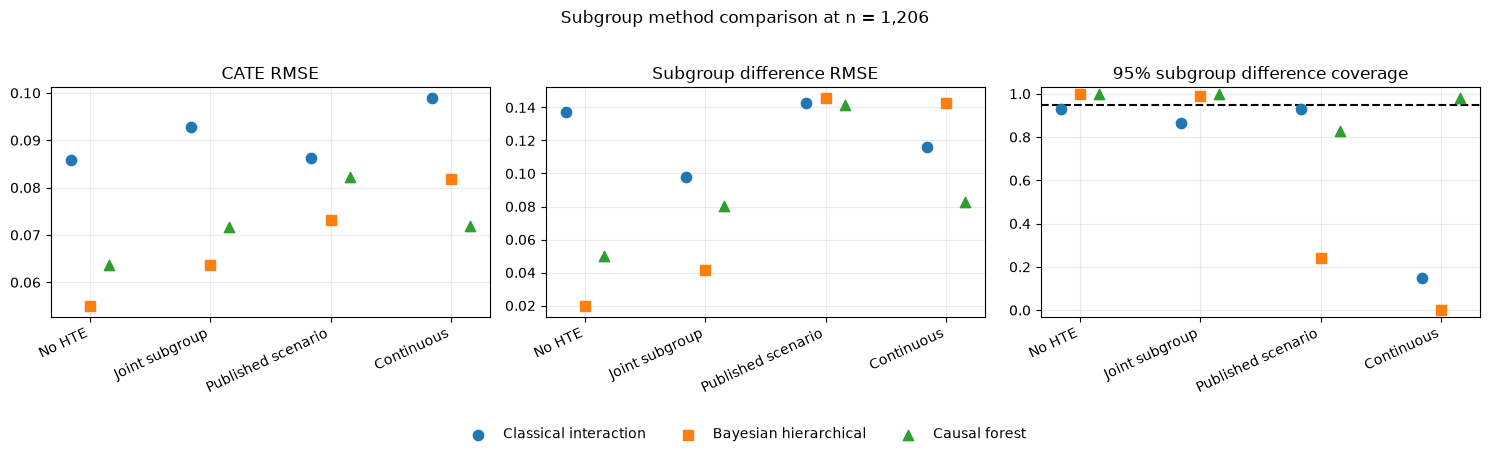

In [18]:
# Run the models or load saved results
if RUN_MAIN_ANALYSIS:
    replication_results = run_main_simulation(replications=N_REPLICATIONS)
    comparison_summary = summarise_main_results(replication_results)
else:
    replication_results = pd.read_csv(OUTPUT_DIRECTORY / "replication_results.csv")
    main_result_columns = {
        "scenario", "method", "success", "converged", "cate_mse",
        "subgroup_difference_error", "subgroup_difference_covered"
    }
    validate_saved_results(
        replication_results, main_result_columns, "main simulation results"
    )
    comparison_summary = pd.read_csv(OUTPUT_DIRECTORY / "summary.csv")
    main_summary_columns = {
        "scenario", "method", "cate_rmse", "subgroup_difference_rmse",
        "subgroup_difference_coverage"
    }
    validate_saved_results(
        comparison_summary, main_summary_columns, "main simulation summary"
    )

# Plot the results
comparison_figure = plot_comparison(
    comparison_summary,
    OUTPUT_DIRECTORY / "model_comparison.png",
    title=f"Subgroup method comparison at n = {cfg.TOTAL_N:,}"
)

## BHM prior sensitivity analysis

This robustness analysis varies one prior component at a time around the
primary mean-prior SD of 2 and heterogeneity-prior scale of 1. It includes
three mean-prior specifications and three heterogeneity-prior specifications,
with the shared primary specification fitted only once. Across four scenarios
and 10 replications per scenario, the five specifications require 200 BHM fits.

In [19]:
def run_prior_sensitivity(replications):
    """Repeat Bayesian fitting under each prespecified prior specification"""
    random_generators = cfg.create_random_generators()
    trial_random_generator = random_generators["prior_trials"]
    model_random_generator = random_generators["prior_models"]
    rows = []
    total_fits = (
        len(cfg.PRIMARY_ANALYSIS_SCENARIOS) * replications * len(PRIOR_SPECIFICATIONS)
    )
    progress = tqdm(
        total=total_fits, desc="BHM prior sensitivity analysis", unit="fit",
        dynamic_ncols=True
    )

    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for replication in range(1, replications + 1):
            # Reuse one trial across prior specifications
            analysis_data = simulate_one_trial(trial_random_generator, scenario)

            # Fit one model for each prior specification
            for prior_specification in PRIOR_SPECIFICATIONS:
                prior_label = prior_specification["label"]
                mean_prior_sd = prior_specification["mean_prior_sd"]
                heterogeneity_prior_scale = prior_specification[
                    "heterogeneity_prior_scale"
                ]
                progress.set_postfix_str(
                    f"{cfg.SCENARIO_LABELS[scenario]} | "
                    f"replication {replication}/{replications} | "
                    f"{prior_label}"
                )
                fit_seed = int(model_random_generator.integers(0, 2**32))

                try:
                    fitted = fit_bayesian_model(
                        analysis_data,
                        evaluation_population,
                        scenario,
                        fit_seed,
                        mean_prior_sd=mean_prior_sd,
                        heterogeneity_prior_scale=heterogeneity_prior_scale
                    )
                    row = make_successful_row(
                        fitted, scenario_truth[scenario], scenario, replication
                    )
                except Exception as exception:
                    row = make_failed_row(
                        "bayesian_hierarchical", scenario, replication, exception
                    )

                # Store both prior parameters with the result
                row["prior_label"] = prior_label
                row["mean_prior_sd"] = mean_prior_sd
                row["heterogeneity_prior_scale"] = heterogeneity_prior_scale
                rows.append(row)
                progress.update(1)

        progress.write(
            f"BHM prior sensitivity analysis completed "
            f"{cfg.SCENARIO_LABELS[scenario]} "
            f"({replications} replications)"
        )

    progress.close()

    # Save detailed sensitivity results
    results = pd.DataFrame(rows)
    results.to_csv(OUTPUT_DIRECTORY / "prior_sensitivity_results.csv", index=False)
    return results

def summarise_prior_results(results):
    """Create one summary row for each scenario and prior specification"""
    rows = []

    # Summarise each scenario and prior specification
    for scenario in cfg.PRIMARY_ANALYSIS_SCENARIOS:
        for prior_specification in PRIOR_SPECIFICATIONS:
            prior_label = prior_specification["label"]
            mean_prior_sd = prior_specification["mean_prior_sd"]
            heterogeneity_prior_scale = prior_specification[
                "heterogeneity_prior_scale"
            ]
            subset = results[
                (results["scenario"] == scenario)
                & (results["prior_label"] == prior_label)
            ]
            row = summarise_subset(subset)
            row["scenario"] = scenario
            row["prior_label"] = prior_label
            row["mean_prior_sd"] = mean_prior_sd
            row["heterogeneity_prior_scale"] = heterogeneity_prior_scale
            row["scenario_label"] = cfg.SCENARIO_LABELS[scenario]
            rows.append(row)

    summary = pd.DataFrame(rows)
    summary.to_csv(OUTPUT_DIRECTORY / "prior_sensitivity_summary.csv", index=False)
    return summary

In [20]:
# Run the sensitivity analysis or load saved results
if RUN_PRIOR_SENSITIVITY:
    prior_sensitivity_results = run_prior_sensitivity(
        replications=cfg.PRIOR_SENSITIVITY_REPLICATIONS
    )
    prior_sensitivity_summary = summarise_prior_results(
        prior_sensitivity_results
    )
else:
    prior_sensitivity_results = pd.read_csv(
        OUTPUT_DIRECTORY / "prior_sensitivity_results.csv"
    )
    prior_result_columns = {
        "scenario", "prior_label", "mean_prior_sd",
        "heterogeneity_prior_scale", "cate_mse",
        "subgroup_difference_error", "subgroup_difference_covered"
    }
    validate_saved_results(
        prior_sensitivity_results, prior_result_columns,
        "BHM prior sensitivity analysis results"
    )
    prior_sensitivity_summary = pd.read_csv(
        OUTPUT_DIRECTORY / "prior_sensitivity_summary.csv"
    )
    prior_summary_columns = {
        "scenario", "prior_label", "mean_prior_sd",
        "heterogeneity_prior_scale", "cate_rmse",
        "subgroup_difference_rmse", "subgroup_difference_coverage"
    }
    validate_saved_results(
        prior_sensitivity_summary, prior_summary_columns,
        "BHM prior sensitivity analysis summary"
    )

prior_sensitivity_summary[
    [
        "scenario_label",
        "prior_label",
        "mean_prior_sd",
        "heterogeneity_prior_scale",
        "usable_replications",
        "cate_rmse",
        "subgroup_difference_rmse",
        "subgroup_difference_coverage",
        "nonconvergence_rate"
    ]
].round(3)

BHM prior sensitivity analysis:  25%|██▌       | 50/200 [01:00<02:45,  1.10s/fit, Joint subgroup | replication 1/10 | Mean-prior SD 1]       

BHM prior sensitivity analysis completed No HTE (10 replications)


BHM prior sensitivity analysis:  50%|█████     | 100/200 [01:52<01:41,  1.02s/fit, Published scenario | replication 1/10 | Mean-prior SD 1]          

BHM prior sensitivity analysis completed Joint subgroup (10 replications)


BHM prior sensitivity analysis:  75%|███████▌  | 150/200 [02:51<01:11,  1.44s/fit, Continuous | replication 1/10 | Mean-prior SD 1]                       

BHM prior sensitivity analysis completed Published scenario (10 replications)


BHM prior sensitivity analysis: 100%|██████████| 200/200 [03:45<00:00,  1.13s/fit, Continuous | replication 10/10 | Heterogeneity-prior scale 2]  

BHM prior sensitivity analysis completed Continuous (10 replications)


,scenario_label,prior_label,mean_prior_sd,heterogeneity_prior_scale,usable_replications,cate_rmse,subgroup_difference_rmse,subgroup_difference_coverage,nonconvergence_rate
0,No HTE,Mean-prior SD 1,1.0,1.0,10,0.059,0.036,1.000,0.0
1,No HTE,Primary,2.0,1.0,10,0.060,0.037,1.000,0.0
2,No HTE,Mean-prior SD 5,5.0,1.0,10,0.060,0.039,1.000,0.0
3,No HTE,Heterogeneity-prior scale 0.5,2.0,0.5,10,0.053,0.024,1.000,0.0
4,No HTE,Heterogeneity-prior scale 2,2.0,2.0,10,0.063,0.045,1.000,0.0
5,Joint subgroup,Mean-prior SD 1,1.0,1.0,10,0.064,0.024,1.000,0.0
6,Joint subgroup,Primary,2.0,1.0,10,0.063,0.023,1.000,0.0
7,Joint subgroup,Mean-prior SD 5,5.0,1.0,10,0.063,0.022,1.000,0.0
8,Joint subgroup,Heterogeneity-prior scale 0.5,2.0,0.5,10,0.059,0.024,1.000,0.0
9,Joint subgroup,Heterogeneity-prior scale 2,2.0,2.0,10,0.065,0.025,1.000,0.0


## Diagnostics and results

The first table counts failed and non-converged fits. The second shows the
reason for every unusable fit. The final table contains the performance
measures used in the study comparison.

In [21]:
# Count fit outcomes
diagnostics = pd.Series(
    {
        "attempted_fits": len(replication_results),
        "successful_fits": int(replication_results["success"].sum()),
        "failed_fits": int((~replication_results["success"]).sum()),
        "nonconverged_fits": int(
            (
                replication_results["success"]
                & ~replication_results["converged"].fillna(False)
            ).sum()
        )
    },
    name="value"
)
diagnostics

attempted_fits       6000
successful_fits      6000
failed_fits             0
nonconverged_fits      20
Name: value, dtype: int64

In [22]:
# Find failed or non-converged fits
successful = replication_results["success"]
converged = replication_results["converged"].fillna(False)
unusable = ~successful | ~converged

replication_results.loc[
    unusable, ["scenario", "replication", "method", "diagnostic", "error"]
]

,scenario,replication,method,diagnostic,error
556,no_hte,186,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
589,no_hte,197,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
649,no_hte,217,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
799,no_hte,267,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
871,no_hte,291,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
973,no_hte,325,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
1150,no_hte,384,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
1861,joint_subgroup,121,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
2164,joint_subgroup,222,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",
2764,joint_subgroup,422,bayesian_hierarchical,"mean prior SD=2, heterogeneity prior scale=1, ...",


In [23]:
# Select the final result columns
result_columns = [
    "scenario_label",
    "method_label",
    "cate_rmse",
    "subgroup_difference_rmse",
    "subgroup_difference_coverage"
]

comparison_summary[result_columns].round(3)

,scenario_label,method_label,cate_rmse,subgroup_difference_rmse,subgroup_difference_coverage
0,No HTE,Classical interaction,0.086,0.137,0.930
1,No HTE,Bayesian hierarchical,0.055,0.020,1.000
2,No HTE,Causal forest,0.064,0.050,1.000
3,Joint subgroup,Classical interaction,0.093,0.098,0.864
4,Joint subgroup,Bayesian hierarchical,0.064,0.042,0.990
5,Joint subgroup,Causal forest,0.072,0.080,1.000
6,Published scenario,Classical interaction,0.086,0.142,0.928
7,Published scenario,Bayesian hierarchical,0.073,0.146,0.241
8,Published scenario,Causal forest,0.082,0.142,0.830
9,Continuous,Classical interaction,0.099,0.116,0.150


## Manuscript-use model comparison figure

In [24]:
comparison_no_title_path = OUTPUT_DIRECTORY / "model_comparison_no_title.png"
comparison_figure_no_title = plot_comparison(
    comparison_summary, comparison_no_title_path
)
plt.close(comparison_figure_no_title)